In [32]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))
parquet_files

[PosixPath('data/futures/6E.parquet'),
 PosixPath('data/futures/6J.parquet'),
 PosixPath('data/futures/CL.parquet'),
 PosixPath('data/futures/ES.parquet'),
 PosixPath('data/futures/GC.parquet'),
 PosixPath('data/futures/NG.parquet'),
 PosixPath('data/futures/NQ.parquet'),
 PosixPath('data/futures/SI.parquet'),
 PosixPath('data/futures/YM.parquet'),
 PosixPath('data/futures/ZB.parquet'),
 PosixPath('data/futures/ZN.parquet')]

In [33]:
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)

    # flatten multi index
    df.columns = [c[0] for c in df.columns]

    df["ticker"] = f.stem
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True, sort=False)
# df = df[df["ticker"] == "6E"]

In [34]:
earliest_per_ticker = df.groupby("ticker")["timestamp"].min().reset_index().sort_values("timestamp")
earliest_per_ticker

,ticker,timestamp
2,CL,2000-08-23
4,GC,2000-08-30
5,NG,2000-08-30
7,SI,2000-08-30
0,6E,2000-09-12
1,6J,2000-09-13
3,ES,2000-09-18
6,NQ,2000-09-18
9,ZB,2000-09-21
10,ZN,2000-09-21


In [35]:
# remove rows with timestamps before 2002-04-05
import datetime
cutoff = datetime.datetime(2002, 4, 5)
df = df[df["timestamp"] >= cutoff].reset_index(drop=True)
df

,timestamp,close,high,low,open,volume,ticker
0,2002-04-05,0.876700,0.878900,0.874800,0.875500,0,6E
1,2002-04-08,0.871600,0.876900,0.871100,0.876700,0,6E
2,2002-04-09,0.878100,0.878500,0.871200,0.872100,0,6E
3,2002-04-10,0.878000,0.880000,0.876400,0.878500,0,6E
4,2002-04-11,0.880700,0.882300,0.876800,0.878000,0,6E
...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [36]:
import numpy as np
import pandas as pd

def get_causal_tokens(df, n_bins=10):
    # 1. Calculate ATR (Trailing only)
    # Using 'high' and 'low' directly for TR to avoid look-ahead
    prev_close = df["close"].shift(1)
    high_low = df["high"] - df["low"]
    high_pc = (df["high"] - prev_close).abs()
    low_pc = (df["low"] - prev_close).abs()
    
    tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()

    # 2. Features
    
    # A. Candle Shape (Differential)
    # How much did we move today relative to vol?
    conviction = (df["close"] - df["open"]) / atr
    explosion = (df["high"] - df["low"]) / atr
    
    # B. Trend Context (Integral) - CRITICAL UPDATE
    # Where are we relative to the 20-day mean? (Proxy for visual trend)
    ma_20 = df["close"].rolling(20).mean()
    trend_score = (df["close"] - ma_20) / atr
    
    # C. Relative Volume
    # Add small epsilon to avoid div by zero
    vol_ma = df["volume"].rolling(50).mean() + 1e-12
    rel_volume = (df["volume"] + 1e-12) / vol_ma

    # 3. Discretization (Fixed Bins to avoid Look-Ahead)
    # We assume standardized features roughly follow N(0,1) or similar.
    # We explicitly define bins rather than learning them from the future.
    
    def digitize_feature(series, min_val, max_val, bins):
        # Clip outliers
        clipped = series.clip(min_val, max_val)
        # Linearly space bins (or you can use norm.ppf for gaussian spacing)
        # This creates integer codes 0 to bins-1
        return pd.cut(clipped, bins=bins, labels=False, include_lowest=True)

    # Conviction: usually within -3 to 3 ATR
    c_codes = digitize_feature(conviction, -3, 3, n_bins)
    
    # Trend: usually within -5 to 5 ATR
    t_codes = digitize_feature(trend_score, -5, 5, n_bins)
    
    # Volume: usually 0 to 5x average
    v_codes = digitize_feature(rel_volume, 0, 5, n_bins)

    # Explosion
    e_codes = digitize_feature(explosion, -3, 3, n_bins)

    # 4. Create Tokens
    # Format: "C{code}_T{code}_V{code}"
    # Using Int64 to handle NaNs gracefully
    df_codes = pd.DataFrame({
        'c': c_codes,
        't': t_codes,
        'v': v_codes,
        "e": e_codes
    }).astype("Int64")

    # Drop early rows where rolling window features are NaN
    df_codes = df_codes.dropna()
    
    tokens = (
        df_codes['c'].astype(str) + "_" + 
        df_codes['t'].astype(str) + "_" + 
        df_codes['v'].astype(str) + "_" + 
        df_codes["e"].astype(str)
    )
    
    # Align indices
    tokens = tokens.reindex(df.index)
    
    return tokens

number_of_classes = 3
feature_bins = 10
# compute tokens per ticker and store back into the main df
df['token'] = None
for _, g in df.groupby('ticker', sort=False):
    df.loc[g.index, 'token']= get_causal_tokens(g, n_bins=feature_bins)

In [37]:
def get_return(df, periods=1):
    # 1. Use Log Returns (Approximates % change, but additive and symmetric)
    # Formula: ln(Price_future / Price_current)
    # We shift 'close' backwards by 'periods' to compare Today vs. Future
    
    future_close = df["close"].shift(-periods)
    
    # Calculate return
    # If future > current, this is positive.
    df["log_ret"] = np.log(future_close / df["close"])
    
    # 2. (Optional but Recommended) Volatility Normalization
    # This matches the "Sharpe Ratio" logic of the paper.
    # We divide the return by the daily volatility (ATR or Std Dev).
    # This helps the model distinguish a "significant move" from noise.
    
    # Calculate 20-day volatility (standard deviation of log returns)
    daily_log_ret = np.log(df["close"] / df["close"].shift(1))
    volatility = daily_log_ret.rolling(20).std()
    
    # The Target: "How many standard deviations will price move?"
    df["target"] = df["log_ret"] / volatility
    
    return df

def get_hurdle_target(df, cost_threshold=0.002): # e.g. 0.2% hurdle
    # ... calc returns ...
    
    # 0 = sell, 1 = neutral, 2 = buy
    df['target'] = 1
    
    # Only buy if return > cost hurdle
    df.loc[df['ret'] > cost_threshold, 'target'] = 1
    
    # Only sell if return < -cost hurdle
    df.loc[df['ret'] < -cost_threshold, 'target'] = 2
    
    return df

def get_target(df, periods=1, sigma_threshold=0.5):
    # --- 1. Calculate Future Return ---
    # Shift backwards to see what happens 'periods' days later
    future_close = df["close"].shift(-periods)
    
    # Log returns (Additive, symmetric)
    df["log_ret"] = np.log(future_close / df["close"])
    
    # --- 2. Normalize by Volatility (The "JKX" Paper Trick) ---
    # Calculate daily volatility (trailing 20 days) to avoid look-ahead
    daily_returns = np.log(df["close"] / df["close"].shift(1))
    volatility = daily_returns.rolling(20).std()
    
    # Calculate "Normalized Return" (Z-Score)
    # Value of 2.0 means price moved 2 standard deviations
    df["norm_ret"] = df["log_ret"] / volatility
    
    # --- 3. Create Classes (The Hurdle) ---
    # We use the Normalized Return for the hurdle
    # 0 = Sell (Significant Down Move)
    # 1 = Neutral (Noise / Small Move)
    # 2 = Buy (Significant Up Move)
    
    # Initialize all as Neutral (1)
    df["target"] = 1
    
    # Buy: If move is > +0.5 sigma
    df.loc[df["norm_ret"] > sigma_threshold, "target"] = 2
    
    # Sell: If move is < -0.5 sigma
    df.loc[df["norm_ret"] < -sigma_threshold, "target"] = 0
    
    # Cleanup: Drop NaN values generated by rolling window and shift
    return df.dropna()

df = get_target(df)
df["target"].value_counts(normalize=True)

/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log

/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



target
1    0.411658
2    0.309496
0    0.278846
Name: proportion, dtype: float64

In [ ]:
bigger_df = pd.read_parquet("data/ibm_data.parquet").rename(columns={"symbol": "ticker"})
bigger_df["token"] = get_causal_tokens(bigger_df)
bigger_df = get_target(bigger_df)
bigger_df = bigger_df.dropna()
# df = bigger_df

massive_df = pd.read_parquet("data/small_group").rename(columns={"symbol": "ticker"})
massive_df["token"] = get_causal_tokens(massive_df)
massive_df = get_target(massive_df)
massive_df = massive_df.dropna()
df = massive_df
df

In [39]:
# align all tickers to a common timestamp index and rebuild a compact (T_common, N, 1) integer array
# pivot tokens so each column is a ticker and index are timestamps
token_pivot = df.pivot(index="timestamp", columns="ticker", values="token").sort_index()
ret_pivot = df.pivot(index="timestamp", columns="ticker", values="target").sort_index()


# keep only timestamps present for every ticker
common_mask = token_pivot.notna().all(axis=1) & ret_pivot.notna().all(axis=1)
T_common = int(common_mask.sum())
print("T_common:", T_common)

# restrict pivot to the common timestamps (ensures every column has the same index)
token_pivot = token_pivot.loc[common_mask]
ret_pivot = ret_pivot.loc[common_mask]

# tickers in consistent order
tickers = token_pivot.columns.tolist()
N = len(tickers)
print("N (tickers):", N, "tickers:", tickers)

# split token strings into three component classes (conviction, explosion, rel_volume)
c_pivot = token_pivot.applymap(lambda s: int(s.split("_")[0]))
t_pivot = token_pivot.applymap(lambda s: int(s.split("_")[1]))
v_pivot = token_pivot.applymap(lambda s: int(s.split("_")[2]))
e_pivot = token_pivot.applymap(lambda s: int(s.split("_")[3]))

# as numpy arrays (T_common, N)
c_arr = c_pivot.values.astype(np.int32)
e_arr = e_pivot.values.astype(np.int32)
t_arr = t_pivot.values.astype(np.int32)
v_arr = v_pivot.values.astype(np.int32)


# combined array with last dim = 3 (conviction, explosion, rel_volume)
class_arr = np.stack([c_arr, e_arr, t_arr, v_arr], axis=-1)

# show result (replace with any further processing you need)
c_pivot.head()

T_common: 3039
N (tickers): 6 tickers: ['WKHS', 'WMS', 'WOR', 'WP', 'WPG', 'ZEUS']


/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/1087201834.py:22: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/1087201834.py:23: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/1087201834.py:24: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/1087201834.py:25: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



ticker,WKHS,WMS,WOR,WP,WPG,ZEUS
timestamp,,,,,,
2018-01-16 14:00:00+00:00,5,4,6,5,4,8
2018-01-16 15:00:00+00:00,4,2,6,5,4,4
2018-01-16 16:00:00+00:00,4,3,3,4,2,3
2018-01-16 17:00:00+00:00,4,3,3,5,2,4
2018-01-16 18:00:00+00:00,4,4,5,4,5,4


In [40]:
ret_pivot

ticker,WKHS,WMS,WOR,WP,WPG,ZEUS
timestamp,,,,,,
2018-01-16 14:00:00+00:00,1.0,0.0,2.0,1.0,0.0,1.0
2018-01-16 15:00:00+00:00,1.0,0.0,0.0,1.0,0.0,0.0
2018-01-16 16:00:00+00:00,1.0,0.0,0.0,1.0,0.0,1.0
2018-01-16 17:00:00+00:00,1.0,0.0,1.0,1.0,1.0,1.0
2018-01-16 18:00:00+00:00,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...
2019-07-30 16:00:00+00:00,1.0,1.0,1.0,1.0,2.0,1.0
2019-07-30 17:00:00+00:00,1.0,1.0,1.0,1.0,0.0,1.0
2019-07-30 18:00:00+00:00,1.0,0.0,1.0,0.0,2.0,0.0


In [41]:
df = df.dropna()
vocab = df["token"].unique().tolist()
vocab_len = len(vocab)

T = len(token_pivot)
N = len(df["ticker"].unique())

T, N

(3039, 6)

In [42]:
# build integer mapping once (vocab is defined in the notebook)
# token_to_id = {tok: i for i, tok in enumerate(range(vocab)}

# allocate array (T,N,1) with integer dtype
all_sequences = np.zeros((T, N, 4), dtype=np.int32)
all_targets = np.zeros((T, N))

for idx, sym in enumerate(tickers):
    seq_ids = np.array([
        c_pivot[sym].astype(np.int32).values, 
        t_pivot[sym].astype(np.int32).values, 
        v_pivot[sym].astype(np.int32).values, 
        e_pivot[sym].astype(np.int32).values
        ])

    # print(seq_ids.T.shape)
    # assert seq_ids.shape[0] == T
    all_sequences[:, idx] = seq_ids.T
    all_targets[:, idx] = ret_pivot[sym].astype(np.int32)

all_sequences.shape, all_sequences.dtype

((3039, 6, 4), dtype('int32'))

In [43]:
all_targets

array([[1., 0., 2., 1., 0., 1.],
       [1., 0., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0., 1.],
       ...,
       [1., 0., 1., 0., 2., 0.],
       [2., 1., 1., 1., 1., 1.],
       [0., 2., 1., 0., 2., 1.]], shape=(3039, 6))

In [44]:
# build dataset

# build dataloader

# instantiate model

# train model

# inspect

In [45]:
from model.my_dataset import MyDataset
from torch.utils.data import DataLoader
from model.model_definition import SimpleTransformer
from model.training import train_loop
import torch

In [46]:
np.unique(all_targets)

array([0., 1., 2.])

In [47]:
class_freqs = np.unique(all_targets, return_counts=True)[1]
class_freqs, number_of_classes

(array([4424, 9372, 4438]), 3)

In [48]:
SEQ_LEN = 8
BATCH_SIZE = 128 # the batches chosen should be set up so that the components of each batch are sequential, then shuffle the order of batches/batches, custom dataloader

train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], SEQ_LEN)
tmp = []
[tmp.append(train_dataset[i]) for i in range(30)]
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], SEQ_LEN)
tmp2 = []
[tmp2.append(val_dataset[i]) for i in range(30, 40)]


train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # pin_memory=True and num_workers=4+
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True) # pin_memory=True and num_workers=4+



# pass frequencies to the model (as a list)
model = SimpleTransformer(feature_bins, SEQ_LEN, number_of_classes, symbol_count=N, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)

res = train_loop(model, train_dataloader, val_dataloader, 50, 4e-4, 1e-5, torch.device("cpu"), "checkpoint", 8)

Training on device: cpu
Trainable parameters: 52899
Training samples: 2424, Validation samples: 601
--------------------------------------------------------------------------------
New best model saved at epoch 1
Epoch: 0 | Train loss: 1.182981854990909 | Val loss: 1.1157800674438476 | LR: 0.0004
New best model saved at epoch 2
Epoch: 1 | Train loss: 1.1266074870762073 | Val loss: 1.0983482360839845 | LR: 0.0004
New best model saved at epoch 3
Epoch: 2 | Train loss: 1.1112777747605975 | Val loss: 1.0964927196502685 | LR: 0.0004
New best model saved at epoch 4
Epoch: 3 | Train loss: 1.1045358118258024 | Val loss: 1.094309186935425 | LR: 0.0004
New best model saved at epoch 5
Epoch: 4 | Train loss: 1.1030763513163517 | Val loss: 1.0935731649398803 | LR: 0.0004
New best model saved at epoch 6
Epoch: 5 | Train loss: 1.101834679904737 | Val loss: 1.092138981819153 | LR: 0.0004
New best model saved at epoch 7
Epoch: 6 | Train loss: 1.0960246450022648 | Val loss: 1.091615581512451 | LR: 0.000

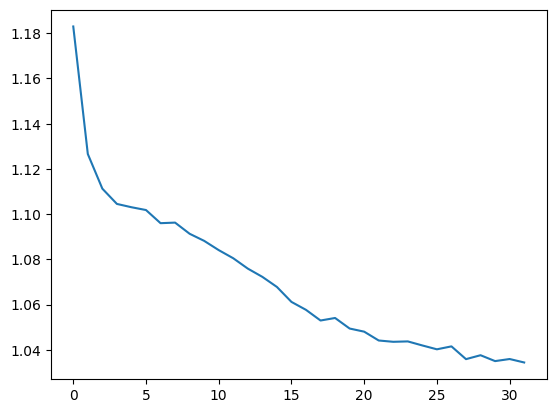

In [49]:
plt.plot(res["history"]["train_loss"])

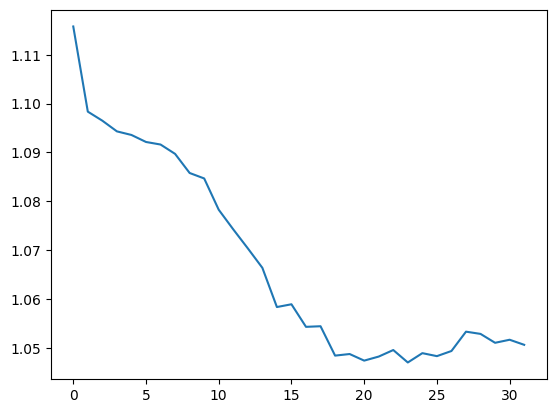

In [50]:
plt.plot(res["history"]["val_loss"])

In [51]:
SEQ_LEN=8
BATCH_SIZE=1

m2 = SimpleTransformer(feature_bins, SEQ_LEN, number_of_classes, symbol_count=N, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)
info = torch.load("checkpoint/best_model.pt")
m2.load_state_dict(info["model_state_dict"])

train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], SEQ_LEN)
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], SEQ_LEN)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE) # pin_memory=True and num_workers=4+
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE) # pin_memory=True and num_workers=4+


In [52]:
model = m2
model.eval()
all_preds = []
with torch.no_grad():
    for x_batch, y_batch in val_dataloader:
        preds, _ = model(x_batch)
        all_preds.append(preds)
        # print(preds)
all_preds

[tensor([[[[0.4116, 0.1933, 0.3951],
           [0.3909, 0.2550, 0.3541],
           [0.4014, 0.2423, 0.3563],
           [0.3708, 0.2723, 0.3569],
           [0.3710, 0.2691, 0.3599],
           [0.4025, 0.2330, 0.3644]]]]),
 tensor([[[[0.3975, 0.1998, 0.4028],
           [0.3905, 0.2527, 0.3568],
           [0.3744, 0.2844, 0.3412],
           [0.2728, 0.4392, 0.2879],
           [0.3390, 0.3313, 0.3297],
           [0.3853, 0.2346, 0.3800]]]]),
 tensor([[[[0.3315, 0.3392, 0.3293],
           [0.0325, 0.9255, 0.0420],
           [0.0298, 0.9286, 0.0416],
           [0.0312, 0.9210, 0.0478],
           [0.0327, 0.9217, 0.0456],
           [0.0627, 0.8547, 0.0826]]]]),
 tensor([[[[0.3934, 0.2054, 0.4012],
           [0.4213, 0.1734, 0.4053],
           [0.4159, 0.1762, 0.4080],
           [0.3829, 0.1968, 0.4203],
           [0.3956, 0.1915, 0.4129],
           [0.4173, 0.1651, 0.4176]]]]),
 tensor([[[[0.3919, 0.2471, 0.3610],
           [0.4163, 0.2305, 0.3532],
           [0.4077, 0.

In [53]:
preds = torch.stack(all_preds).squeeze(1).squeeze(1)
preds.shape # (timesteps, N, output_classes)

torch.Size([601, 6, 3])

In [54]:
# preds: torch.Tensor with shape (T, N)
# select top-2 indices per row and produce a boolean one-hot mask (True for top-2)
topk = preds.topk(2, dim=-1)
bottomk = (-preds).topk(2, dim=-1)
top2_idx = topk.indices  # shape (T, 2)
b2_idx = bottomk.indices

top2_mask = torch.zeros_like(preds, dtype=torch.bool)  # (T, N)
rows = torch.arange(preds.size(0), device=preds.device).unsqueeze(1)  # (T, 1)
top2_mask[rows, top2_idx] = True

b2_mask = torch.zeros_like(preds, dtype=torch.bool)  # (T, N)
rows = torch.arange(preds.size(0), device=preds.device).unsqueeze(1)  # (T, 1)
b2_mask[rows, b2_idx] = True

# top2_mask is a boolean tensor with True at the two highest entries per row
top2_mask_np = top2_mask.cpu().numpy()  # optional NumPy boolean array
b2_mask_np = b2_mask.cpu().numpy()

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [601, 1], [601, 6, 2]

In [ ]:
preds

tensor([[[0.3481, 0.3268, 0.3251],
         [0.3506, 0.3127, 0.3367],
         [0.3226, 0.3745, 0.3029],
         ...,
         [0.3235, 0.3539, 0.3226],
         [0.3578, 0.3170, 0.3252],
         [0.3637, 0.3032, 0.3330]],

        [[0.3475, 0.3076, 0.3448],
         [0.3376, 0.3198, 0.3427],
         [0.3386, 0.3500, 0.3113],
         ...,
         [0.3252, 0.3351, 0.3398],
         [0.3674, 0.2980, 0.3347],
         [0.3588, 0.3007, 0.3405]],

        [[0.3323, 0.3222, 0.3455],
         [0.3447, 0.3279, 0.3274],
         [0.3530, 0.3018, 0.3452],
         ...,
         [0.3176, 0.3467, 0.3357],
         [0.3606, 0.3024, 0.3370],
         [0.3605, 0.3067, 0.3328]],

        ...,

        [[0.3536, 0.3095, 0.3369],
         [0.3515, 0.3219, 0.3266],
         [0.3358, 0.3286, 0.3356],
         ...,
         [0.2908, 0.3910, 0.3181],
         [0.3534, 0.3212, 0.3254],
         [0.3500, 0.3229, 0.3271]],

        [[0.3439, 0.3263, 0.3298],
         [0.3480, 0.3234, 0.3286],
         [0.

In [ ]:
long_signal = preds[:, :, 2] > 0.35
short_signal = preds[:, :, 0] > 0.35
neutral = ~(long_signal | short_signal)  # elementwise NOT of the elementwise OR
neutral

tensor([[ True, False,  True,  ...,  True, False, False],
        [ True,  True,  True,  ...,  True, False, False],
        [ True,  True, False,  ...,  True, False, False],
        ...,
        [False, False,  True,  ...,  True, False,  True],
        [ True,  True,  True,  ...,  True, False, False],
        [ True, False,  True,  ...,  True,  True, False]])

In [ ]:
long_signal.sum(), short_signal.sum()

(tensor(466), tensor(4685))

In [ ]:
close_prices = []
for _, g in df.groupby("ticker"):
    close_price = g[-preds.shape[0]:].sort_index()["close"].values
    close_prices.append(close_price)

close_prices = np.stack(close_prices).T
close_prices.shape

(1166, 11)

Start                                                   0
End                                                  1165
Period                                 1166 days 00:00:00
Start Value                                         100.0
End Value                                      124.999332
Total Return [%]                                24.999332
Benchmark Return [%]                            39.723044
Max Gross Exposure [%]                              100.0
Total Fees Paid                                  1.198121
Max Drawdown [%]                                   47.167
Max Drawdown Duration         597 days 06:32:43.636363640
Total Trades                                    28.454545
Total Closed Trades                             27.454545
Total Open Trades                                     1.0
Open Trade PnL                                  13.507611
Win Rate [%]                                    49.266937
Best Trade [%]                                  16.902802
Worst Trade [%

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_91341/1673100331.py:13: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x10763b100>. Pass column to select a single column/group.



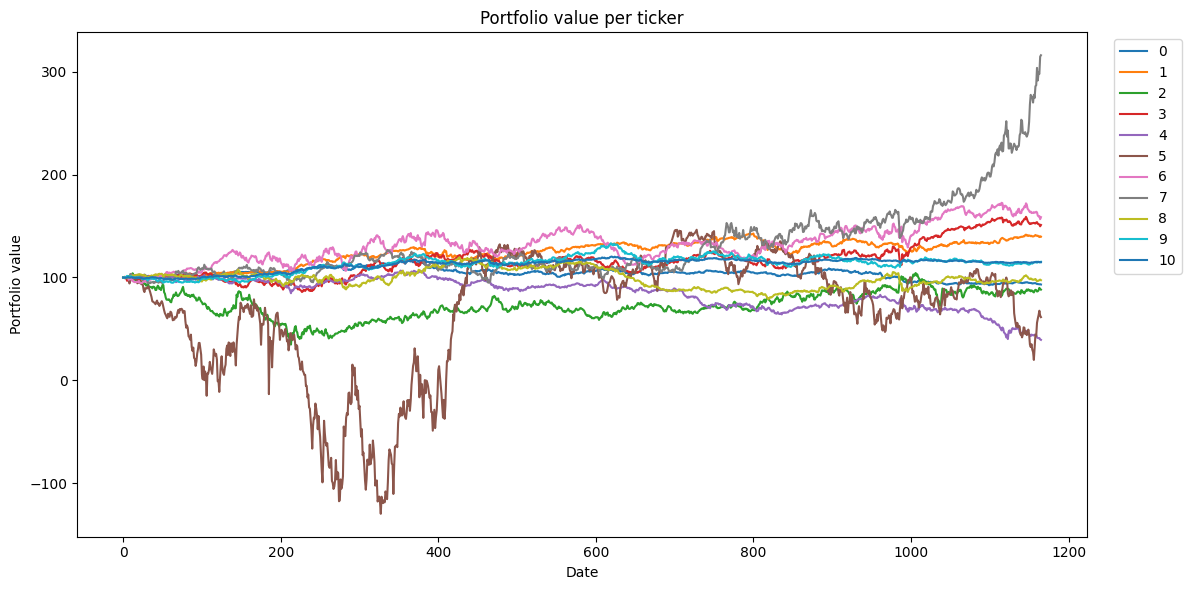

In [ ]:
import vectorbt as vbt

portfolio = vbt.Portfolio.from_signals(
    close = close_prices,
    entries = long_signal,
    exits = short_signal,
    short_entries = short_signal,
    short_exits = long_signal,
    fees = 0.0002,
    freq = "1d"
)

st = portfolio.stats()
print(st)
# plot equity curves using pandas / matplotlib (supports multiple columns)
pf_value = portfolio.value()  # DataFrame with index=dates and columns=tickers
pf_value.plot(figsize=(12, 6))
plt.title("Portfolio value per ticker")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend(loc="best", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

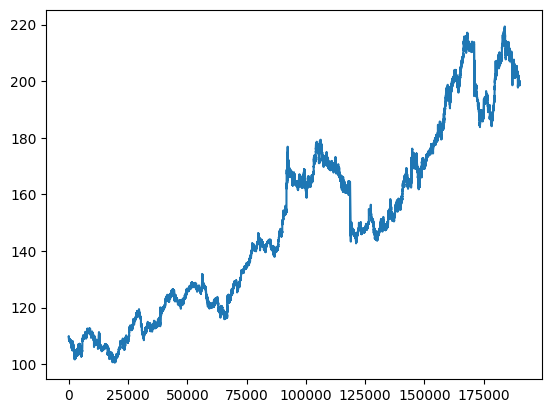

In [ ]:
plt.plot(close_prices-20)

(array([1.9000e+01, 1.5800e+02, 3.0000e+02, 3.8300e+02, 4.7800e+02,
        5.7700e+02, 6.5200e+02, 8.6100e+02, 1.0160e+03, 1.1860e+03,
        1.3730e+03, 1.6830e+03, 2.2520e+03, 3.2670e+03, 5.4900e+03,
        1.0969e+04, 2.3836e+04, 4.1620e+04, 4.5666e+04, 2.9074e+04,
        1.1902e+04, 3.8520e+03, 1.1040e+03, 4.1100e+02, 2.7900e+02,
        2.1300e+02, 1.9900e+02, 1.6100e+02, 1.3000e+02, 1.2200e+02,
        1.2800e+02, 1.2000e+02, 8.3000e+01, 7.0000e+01, 6.5000e+01,
        4.5000e+01, 5.1000e+01, 5.4000e+01, 4.9000e+01, 2.9000e+01,
        3.5000e+01, 2.6000e+01, 3.7000e+01, 3.0000e+01, 2.7000e+01,
        2.2000e+01, 2.5000e+01, 1.0000e+01, 1.6000e+01, 1.0000e+01]),
 array([0.09920772, 0.11225701, 0.12530631, 0.1383556 , 0.15140489,
        0.16445419, 0.17750347, 0.19055277, 0.20360206, 0.21665135,
        0.22970065, 0.24274993, 0.25579923, 0.26884851, 0.28189781,
        0.29494712, 0.30799639, 0.3210457 , 0.33409497, 0.34714428,
        0.36019358, 0.37324286, 0.38629216, 0.

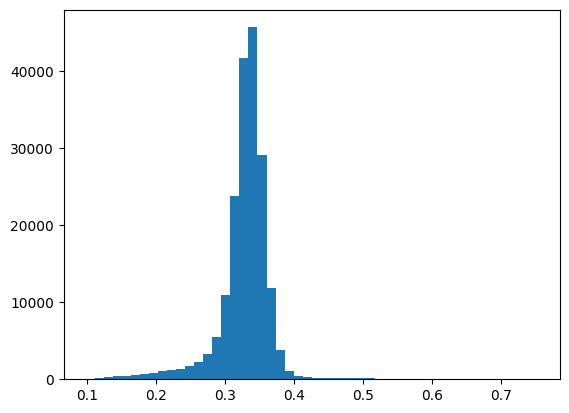

In [ ]:
plt.hist(preds[:, 0, 0], bins=50)